## Check the window function

In [1]:
import os, sys
import lsstypes as types
import numpy as np
from matplotlib import pyplot as plt

sys.path.append('../../')
from helper import REDSHIFT_BIN_LSS

In [2]:
def unpack_obs(result):
    k = result.get(ells=0).coords('k')
    pk = [result.get(ells=ell).values()['value'] for ell in result.ells]
    return k, pk

In [3]:
tracer = 'LRG'
zrange = REDSHIFT_BIN_LSS[tracer][0]

local_fn = f'/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/LRG/mock0/mpspk/window_mesh2_spectrum_poles_{tracer}_z{zrange[0]}-{zrange[1]}_DR2_v2.0.h5'
save_fn  = f'/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/abacus-hf-dr2-v2-altmtl/mock0/window_mesh2_spectrum_poles_{tracer}_z{zrange[0]}-{zrange[1]}_GCcomb_weight-default-FKP.h5'
print(local_fn)
print(save_fn)

win1 =types.read(local_fn)
win2 =types.read(save_fn)

W1 = win1.value().real
W2 = win2.value().real

/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/LRG/mock0/mpspk/window_mesh2_spectrum_poles_LRG_z0.4-0.6_DR2_v2.0.h5
/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/abacus-hf-dr2-v2-altmtl/mock0/window_mesh2_spectrum_poles_LRG_z0.4-0.6_GCcomb_weight-default-FKP.h5


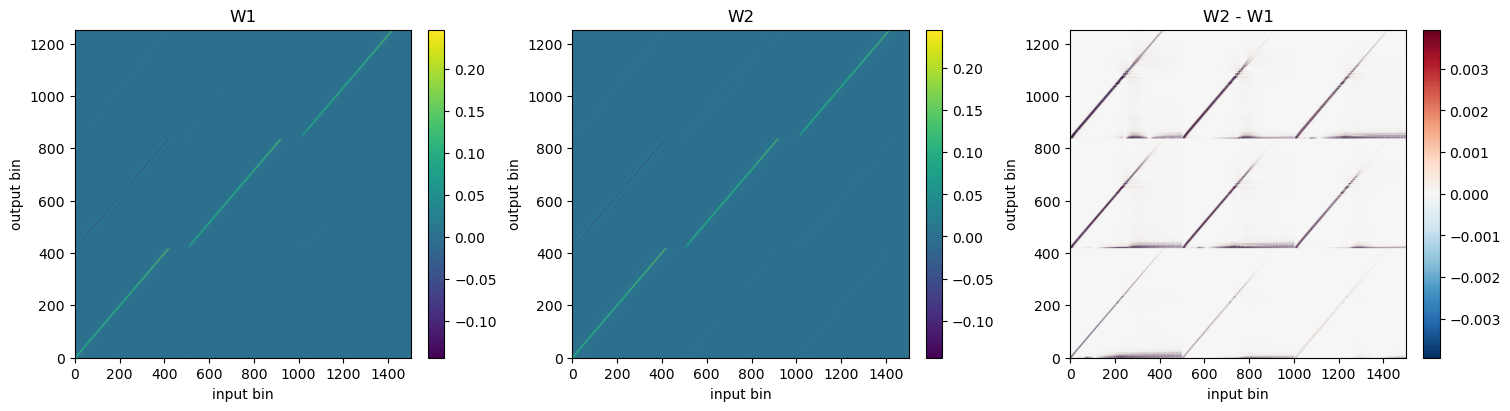

In [4]:
dW = W1-W2

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axes[0].imshow(W1, aspect="auto", origin="lower")
axes[0].set_title("W1")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(W2, aspect="auto", origin="lower")
axes[1].set_title("W2")
plt.colorbar(im1, ax=axes[1])

vmax = np.nanpercentile(np.abs(dW), 99)
im2 = axes[2].imshow(dW, aspect="auto", origin="lower", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
axes[2].set_title("W2 - W1")
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel("input bin")
    ax.set_ylabel("output bin")

{'norm_y1': 11.152121862488054,
 'norm_y2': 11.150650972245673,
 'relative_output_diff': 0.0008770088206752366,
 'rms_output_diff': 0.000276193020487113,
 'max_abs_output_diff': 0.005709309564186471,
 'mean_abs_output_diff': 4.5667539542576654e-05}

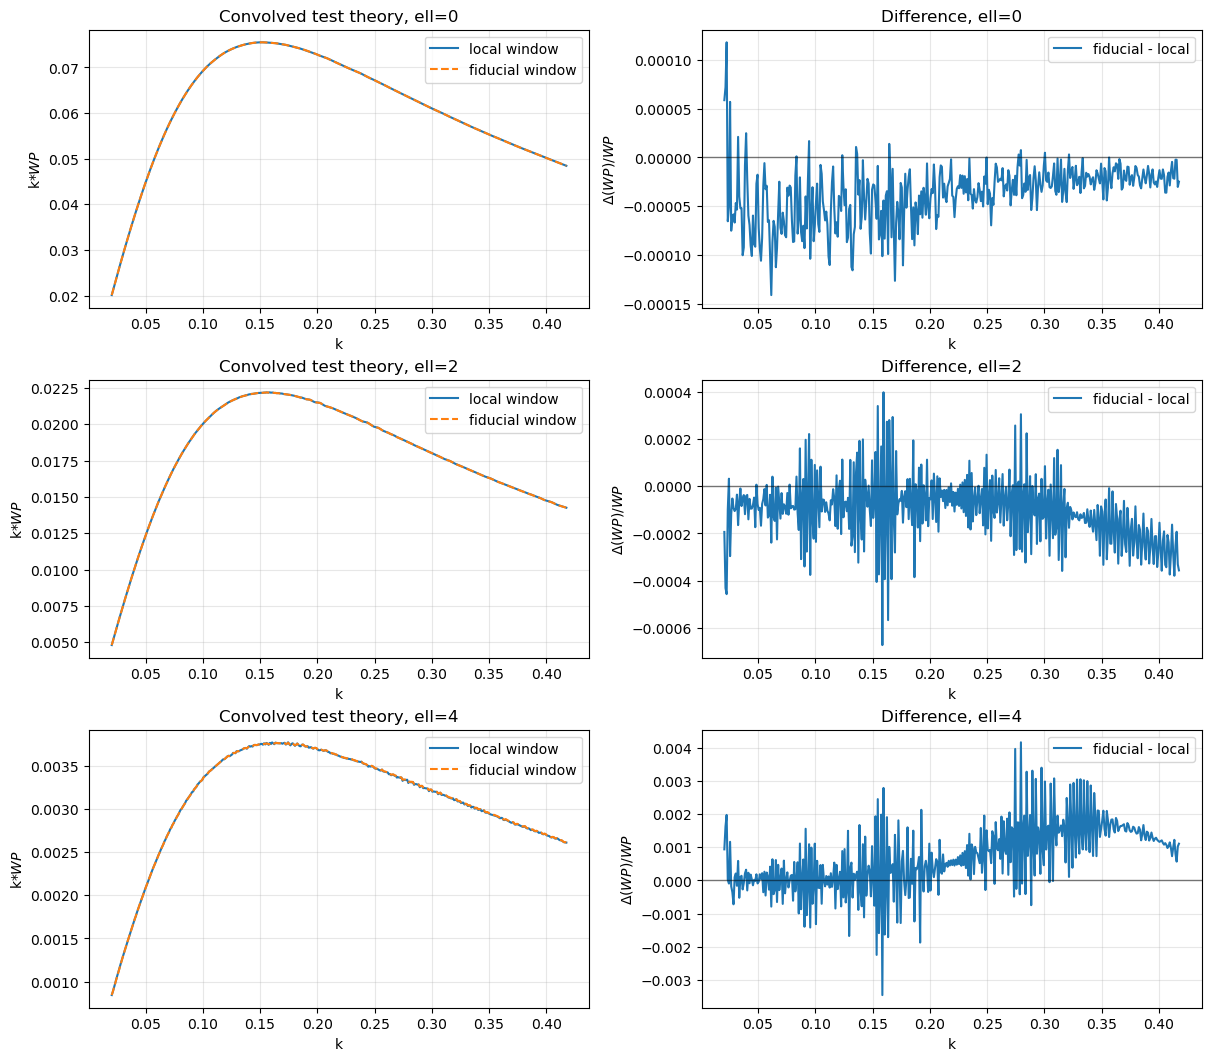

In [6]:
kout, _ = unpack_obs(win1.observable)
kout = np.asarray(kout)
nout = len(kout)

kin, pk_zero = unpack_obs(win1.theory)
kin = np.asarray(kin)
n = len(kin)

W1 = win1.value().real
W2 = win2.value().real

assert W1.shape[1] % n == 0, (W1.shape[1], n)
nell_in = W1.shape[1] // n

# Simple nonzero smooth test theory.
# Ordering: [P0(k), P2(k), P4(k)]
pk = np.zeros((nell_in, n))
pk[0] = 1.0 / (1.0 + (kin / 0.15)**2)

if nell_in > 1:
    pk[1] = 0.3 * pk[0]
if nell_in > 2:
    pk[2] = 0.05 * pk[0]

theory_in = pk.reshape(-1)

y1 = W1 @ theory_in
y2 = W2 @ theory_in
dy = y2 - y1

den = np.linalg.norm(y1)

assert W1.shape[0] % nout == 0, (W1.shape[0], nout)
nell_out = W1.shape[0] // nout

ells = list(win1.observable.ells)

fig, axes = plt.subplots(nell_out, 2, figsize=(12, 3.5 * nell_out), constrained_layout=True)

if nell_out == 1:
    axes = np.array([axes])

ncut=20
kout = kout[ncut:]

for iell in range(nell_out):
    sl = slice(iell * nout, (iell + 1) * nout)
    ell = ells[iell]

    y1_ell = y1[sl][ncut:]
    y2_ell = y2[sl][ncut:]
    dy_ell = dy[sl][ncut:]

    axes[iell, 0].plot(kout, kout*y1_ell, label="local window")
    axes[iell, 0].plot(kout, kout*y2_ell, "--", label="fiducial window")
    axes[iell, 0].set_title(f"Convolved test theory, ell={ell}")
    axes[iell, 0].set_xlabel("k")
    axes[iell, 0].set_ylabel(r"k*$W P$")
    axes[iell, 0].grid(alpha=0.3)
    axes[iell, 0].legend()

    axes[iell, 1].plot(kout, dy_ell/y1_ell, label="fiducial - local")
    axes[iell, 1].axhline(0, color="k", lw=1, alpha=0.5)
    axes[iell, 1].set_title(f"Difference, ell={ell}")
    axes[iell, 1].set_xlabel("k")
    axes[iell, 1].set_ylabel(r"$\Delta(WP)/ WP$")
    axes[iell, 1].grid(alpha=0.3)
    axes[iell, 1].legend()

In [7]:
tracer = 'QSO'
region = 'NGC'
zrange = REDSHIFT_BIN_LSS[tracer][0]

local_fn = f'/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/QSO/mock0/mpspk/window_mesh3_spectrum_poles_sugiyama_{tracer}_z{zrange[0]}-{zrange[1]}_{region}_DR2_v2.0.h5'
save_fn  = f'/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/abacus-hf-dr2-v2-altmtl/mock0/window_mesh3_spectrum_sugiyama-diagonal_poles_{tracer}_z{zrange[0]}-{zrange[1]}_{region}_weight-default-FKP.h5'
print(local_fn)
print(save_fn)

win1 =types.read(local_fn)
win2 =types.read(save_fn)

W1 = win1.value().real
W2 = win2.value().real

/pscratch/sd/s/shengyu/galaxies/catalogs/Y3/AbacusHF-v2/altmtl/QSO/mock0/mpspk/window_mesh3_spectrum_poles_sugiyama_QSO_z0.8-2.1_NGC_DR2_v2.0.h5
/global/cfs/cdirs/desi/science/cai/desi-clustering/dr2/summary_statistics/full_shape/base/abacus-hf-dr2-v2-altmtl/mock0/window_mesh3_spectrum_sugiyama-diagonal_poles_QSO_z0.8-2.1_NGC_weight-default-FKP.h5


{'0_0_0': {'median_frac_diff': 0.0010031941006787717,
  'mean_frac_diff': 0.0015040614701037189,
  'min_frac_diff': 0.00021352883534476262,
  'max_frac_diff': 0.004430746659454627,
  'max_abs_frac_diff': 0.004430746659454627},
 '2_0_2': {'median_frac_diff': 0.0004174349155179531,
  'mean_frac_diff': 0.0005295162023478785,
  'min_frac_diff': 8.644042142370526e-05,
  'max_frac_diff': 0.0010909582355750431,
  'max_abs_frac_diff': 0.0010909582355750431}}

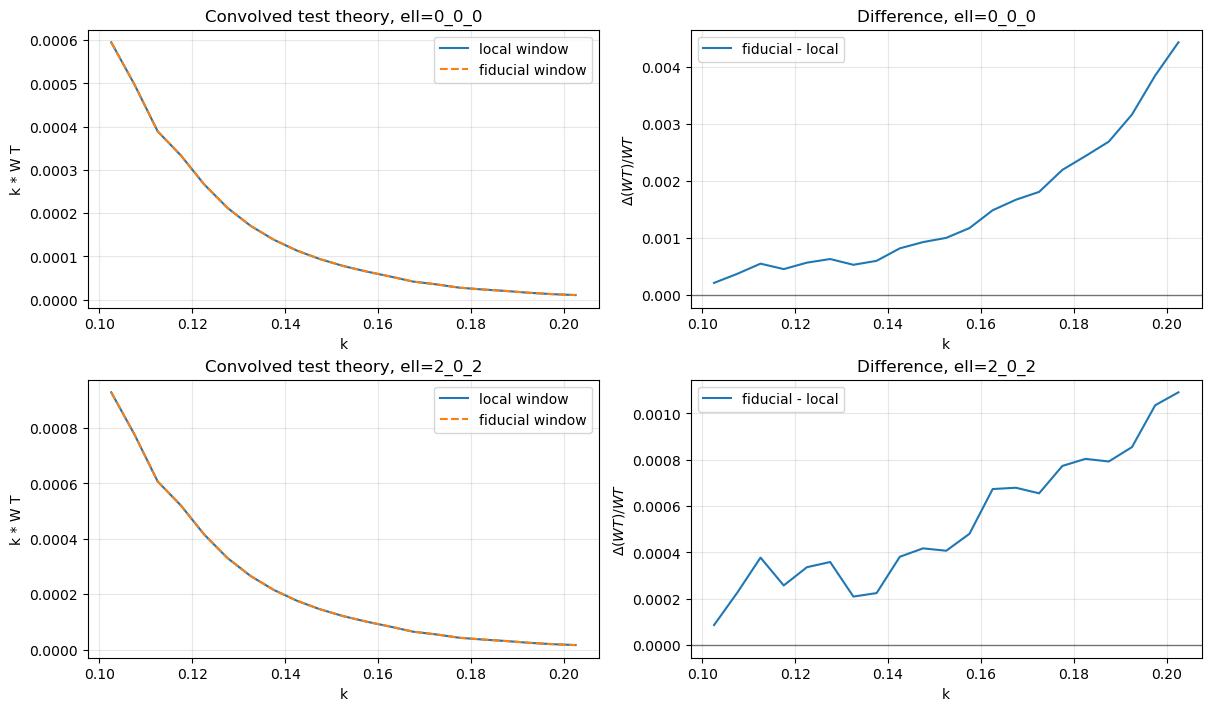

In [9]:
import h5py


def _window_groups(fn, root):
    with h5py.File(fn, "r") as f:
        return [k for k in f[root].keys() if isinstance(f[f"{root}/{k}"], h5py.Group)]

def _smooth_bk_theory_from_window(fn):
    """Build a smooth nonzero test theory vector in the same order as window.value columns."""
    theory = []
    with h5py.File(fn, "r") as f:
        theory_groups = [k for k in f["theory"].keys() if isinstance(f[f"theory/{k}"], h5py.Group)]
        for group in theory_groups:
            kval = f[f"theory/{group}/k"][:]
            k1, k2 = kval[:, 0], kval[:, 1]
            ell_part = group.split("-")[0]
            ell_amp = 1.0 + 0.15 * sum(int(value) for value in ell_part.split("_"))
            theory.append(ell_amp * np.exp(-18.0 * (k1 + k2)) / (1.0 + (k1 / 0.08)**2 + (k2 / 0.08)**2))
    return np.concatenate(theory)

W1 = win1.value().real
W2 = win2.value().real
obs_ells = _window_groups(local_fn, "observable")
theory_ells = _window_groups(local_fn, "theory")
assert obs_ells == _window_groups(save_fn, "observable")
assert theory_ells == _window_groups(save_fn, "theory")

# Use each window's own theory grid. For this QSO comparison these vectors are identical,
# but this keeps the test robust if the grids ever differ slightly.
theory1 = _smooth_bk_theory_from_window(local_fn)
theory2 = _smooth_bk_theory_from_window(save_fn)

# Window-convolved theory.
y1 = W1 @ theory1
y2 = W2 @ theory2
dy = y2 - y1

with h5py.File(local_fn, "r") as f:
    kout = f[f"observable/{obs_ells[0]}/k"][:, 0]
kout = np.asarray(kout)
nout = len(kout)

assert W1.shape[0] % nout == 0, (W1.shape[0], nout)
nell_out = W1.shape[0] // nout
assert nell_out == len(obs_ells), (nell_out, obs_ells)

fig, axes = plt.subplots(nell_out, 2, figsize=(12, 3.5 * nell_out), constrained_layout=True)
if nell_out == 1:
    axes = np.array([axes])

ncut = 20
kplot = kout[ncut:]
stats = {}

for iell, ell in enumerate(obs_ells):
    sl = slice(iell * nout, (iell + 1) * nout)
    y1_ell = y1[sl][ncut:]
    y2_ell = y2[sl][ncut:]
    dy_ell = dy[sl][ncut:]
    good = np.isfinite(y1_ell) & (np.abs(y1_ell) > 1e-30)
    frac = dy_ell[good] / y1_ell[good]

    stats[ell] = {
        "median_frac_diff": np.median(frac),
        "mean_frac_diff": np.mean(frac),
        "min_frac_diff": np.min(frac),
        "max_frac_diff": np.max(frac),
        "max_abs_frac_diff": np.max(np.abs(frac)),
    }

    axes[iell, 0].plot(kplot, kplot * y1_ell, label="local window")
    axes[iell, 0].plot(kplot, kplot * y2_ell, "--", label="fiducial window")
    axes[iell, 0].set_title(f"Convolved test theory, ell={ell}")
    axes[iell, 0].set_xlabel("k")
    axes[iell, 0].set_ylabel(r"k * W T")
    axes[iell, 0].grid(alpha=0.3)
    axes[iell, 0].legend()

    axes[iell, 1].plot(kplot[good], frac, label="fiducial - local")
    axes[iell, 1].axhline(0, color="k", lw=1, alpha=0.5)
    axes[iell, 1].set_title(f"Difference, ell={ell}")
    axes[iell, 1].set_xlabel("k")
    axes[iell, 1].set_ylabel(r"$\Delta(WT) / WT$")
    axes[iell, 1].grid(alpha=0.3)
    axes[iell, 1].legend()

stats
